# Ablation Study | Feature Contribution to Risk Classification
## Barcelona Urban Safety Classification

**Purpose:** Quantify how much each of the 7 spatial features contributes to classification performance. We train Logistic Regression and Random Forest on all 7 features (the *baseline*), then retrain with one feature removed at a time and measure the accuracy drop.

A large drop when a feature is removed -> that feature carries significant information.  
A small or zero drop - the remaining features can compensate, or the feature is redundant.

**Note:** The target labels are K-Means pseudo-labels from `03_KMeans.ipynb`, so accuracy measures how well the model reproduces the cluster boundary - not ground-truth crime outcomes. Nonetheless, the relative drops are a valid signal of feature importance within this pipeline.

In [ ]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120

REPO_ROOT = Path('..').resolve()
CSV_PATH = REPO_ROOT / 'csv' / 'segment_risk_classified.csv'
PLOT_DIR = REPO_ROOT / 'notebooks' / 'plots' / 'ablation'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RISK_ORDER   = ['low', 'medium', 'high']
RISK_COLORS  = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c' }

: 

## Step 1: Load Data

In [3]:
FEATURE_COLS = [
    'lighting_norm',
    'visibility_norm',
    'connectivity_norm',
    'enclosure_norm',
    'dominant_land_use_score_norm',
    'public_transport_proximity_m_norm',
    'pedestrian_priority_score_norm'
]

FEATURE_LABELS = {
    'lighting_norm':                    'Lighting',
    'visibility_norm':                  'Visibility',
    'connectivity_norm':                'Connectivity',
    'enclosure_norm':                   'Enclosure',
    'dominant_land_use_score_norm':     'Land Use Score',
    'public_transport_proximity_m_norm':'Transport Proximity',
    'pedestrian_priority_score_norm':   'Pedestrian Priority Score'
}
clean_name = lambda col: FEATURE_LABELS.get(col, col.replace('_norm', ''))

csv_path = CSV_PATH
df = pd.read_csv(csv_path)

# Ensure FEATURE_COLS only contains columns present in the dataframe
present_features = [f for f in FEATURE_COLS if f in df.columns]
missing = [f for f in FEATURE_COLS if f not in df.columns]
if missing:
    print(f"Warning: the following features are missing from CSV and will be skipped: {missing}")
    FEATURE_COLS = present_features

# Drop rows with missing features or labels
if len(FEATURE_COLS) == 0:
    raise ValueError('No feature columns available in dataframe to run ablation.')

df = df.dropna(subset=FEATURE_COLS + ['risk_class']).reset_index(drop=True)
df['risk_class'] = pd.Categorical(df['risk_class'], categories=RISK_ORDER, ordered=True)

print(f'Loaded {len(df):,} segments')
print(f'Using features: {FEATURE_COLS}')
print(f'Risk class distribution:')
print(df['risk_class'].value_counts().reindex(RISK_ORDER))

Loaded 30,959 segments
Using features: ['lighting_norm', 'visibility_norm', 'connectivity_norm', 'enclosure_norm', 'dominant_land_use_score_norm', 'public_transport_proximity_m_norm', 'pedestrian_priority_score_norm']
Risk class distribution:
risk_class
low       14670
medium     8800
high       7489
Name: count, dtype: int64


## Step 2: Establish Baseline (All 7 Features)

We replicate the exact setup from `05_ClassificationML.ipynb` to get the baseline accuracy for both models.

In [4]:
def train_and_evaluate(feature_subset, df, random_state=42):
    """Train LR and RF on `feature_subset`, return accuracy metrics dict."""
    X = df[feature_subset].values
    y = df['risk_class'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    # Logistic Regression
    lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=random_state)
    lr.fit(X_train_s, y_train)
    cv_lr = cross_val_score(lr, X_train_s, y_train, cv=cv, scoring='accuracy')

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    rf.fit(X_train_s, y_train)
    cv_rf = cross_val_score(rf, X_train_s, y_train, cv=cv, scoring='accuracy')

    return {
        'lr_test':  accuracy_score(y_test, lr.predict(X_test_s)),
        'lr_cv':    cv_lr.mean(),
        'lr_cv_std':cv_lr.std(),
        'rf_test':  accuracy_score(y_test, rf.predict(X_test_s)),
        'rf_cv':    cv_rf.mean(),
        'rf_cv_std':cv_rf.std(),
    }

print('Training baseline (all 7 features)...')
baseline = train_and_evaluate(FEATURE_COLS, df)
print(f"  LR  — test: {baseline['lr_test']:.4f}  |  CV: {baseline['lr_cv']:.4f} Â± {baseline['lr_cv_std']:.4f}")
print(f"  RF  — test: {baseline['rf_test']:.4f}  |  CV: {baseline['rf_cv']:.4f} Â± {baseline['rf_cv_std']:.4f}")

Training baseline (all 7 features)...
  LR  — test: 0.9919  |  CV: 0.9897 Â± 0.0008
  RF  — test: 0.9829  |  CV: 0.9801 Â± 0.0022


## Step 3: Leave-One-Out Ablation

We retrain with each feature removed in turn and record the accuracy delta relative to the baseline.  
A **negative delta** means removing that feature hurt performance (the feature was useful).  
A **positive delta** means removing it had no effect or slightly helped (possible redundancy or noise).

In [7]:
rows = []

for dropped in FEATURE_COLS:
    subset = [f for f in FEATURE_COLS if f != dropped]
    label  = clean_name(dropped)
    print(f'  Dropping: {label}...')
    metrics = train_and_evaluate(subset, df)
    rows.append({
        'dropped_feature': label,
        'lr_test':         metrics['lr_test'],
        'lr_cv':           metrics['lr_cv'],
        'lr_cv_std':       metrics['lr_cv_std'],
        'rf_test':         metrics['rf_test'],
        'rf_cv':           metrics['rf_cv'],
        'rf_cv_std':       metrics['rf_cv_std'],
        'lr_test_delta':   metrics['lr_test'] - baseline['lr_test'],
        'lr_cv_delta':     metrics['lr_cv']   - baseline['lr_cv'],
        'rf_test_delta':   metrics['rf_test'] - baseline['rf_test'],
        'rf_cv_delta':     metrics['rf_cv']   - baseline['rf_cv'],
    })

ablation_df = pd.DataFrame(rows)
print('\nDone.')

  Dropping: Lighting...
  Dropping: Visibility...
  Dropping: Connectivity...
  Dropping: Enclosure...
  Dropping: Land Use Score...
  Dropping: Transport Proximity...
  Dropping: Pedestrian Priority Score...

Done.


## Step 4: Results Table

In [ ]:
print('=' * 90)
print(f'ABLATION STUDY RESULTS  (baseline LR={baseline["lr_test"]:.4f}, RF={baseline["rf_test"]:.4f})')
print('=' * 90)
print(f'{"Feature Dropped":<25} {"LR Test":>9} {"LR Î”":>8} {"LR CV":>9} {"RF Test":>9} {"RF Î”":>8} {"RF CV":>9}')
print('-' * 90)

for _, row in ablation_df.iterrows():
    print(
        f"{row['dropped_feature']:<25}"
        f"{row['lr_test']:>9.4f}"
        f"{row['lr_test_delta']:>+8.4f}"
        f"{row['lr_cv']:>9.4f}"
        f"{row['rf_test']:>9.4f}"
        f"{row['rf_test_delta']:>+8.4f}"
        f"{row['rf_cv']:>9.4f}"
    )

print('-' * 90)
print(f"{'BASELINE (all 7)':<25}{baseline['lr_test']:>9.4f}{'':>8}{baseline['lr_cv']:>9.4f}"
      f"{baseline['rf_test']:>9.4f}{'':>8}{baseline['rf_cv']:>9.4f}")

ABLATION STUDY RESULTS  (baseline LR=0.9979, RF=0.9712)
Feature Dropped             LR Test     LR Î”     LR CV   RF Test     RF Î”     RF CV
------------------------------------------------------------------------------------------
Lighting                    0.9568 -0.0411   0.9578   0.9664 -0.0049   0.9514
Visibility                  0.9131 -0.0848   0.9094   0.9608 -0.0104   0.9456
Connectivity                0.8185 -0.1794   0.8101   0.9407 -0.0306   0.9037
Enclosure                   0.8731 -0.1248   0.8742   0.9493 -0.0220   0.9219
Land Use Score              0.8093 -0.1886   0.8033   0.9397 -0.0315   0.9052
Transport Proximity         0.7000 -0.2979   0.6882   0.9101 -0.0611   0.8582
Pedestrian Priority Score   0.8081 -0.1898   0.8161   0.9364 -0.0349   0.9086
------------------------------------------------------------------------------------------
BASELINE (all 6)            0.9979           0.9969   0.9712           0.9581


## Step 5: Visualise - Accuracy Drop per Feature

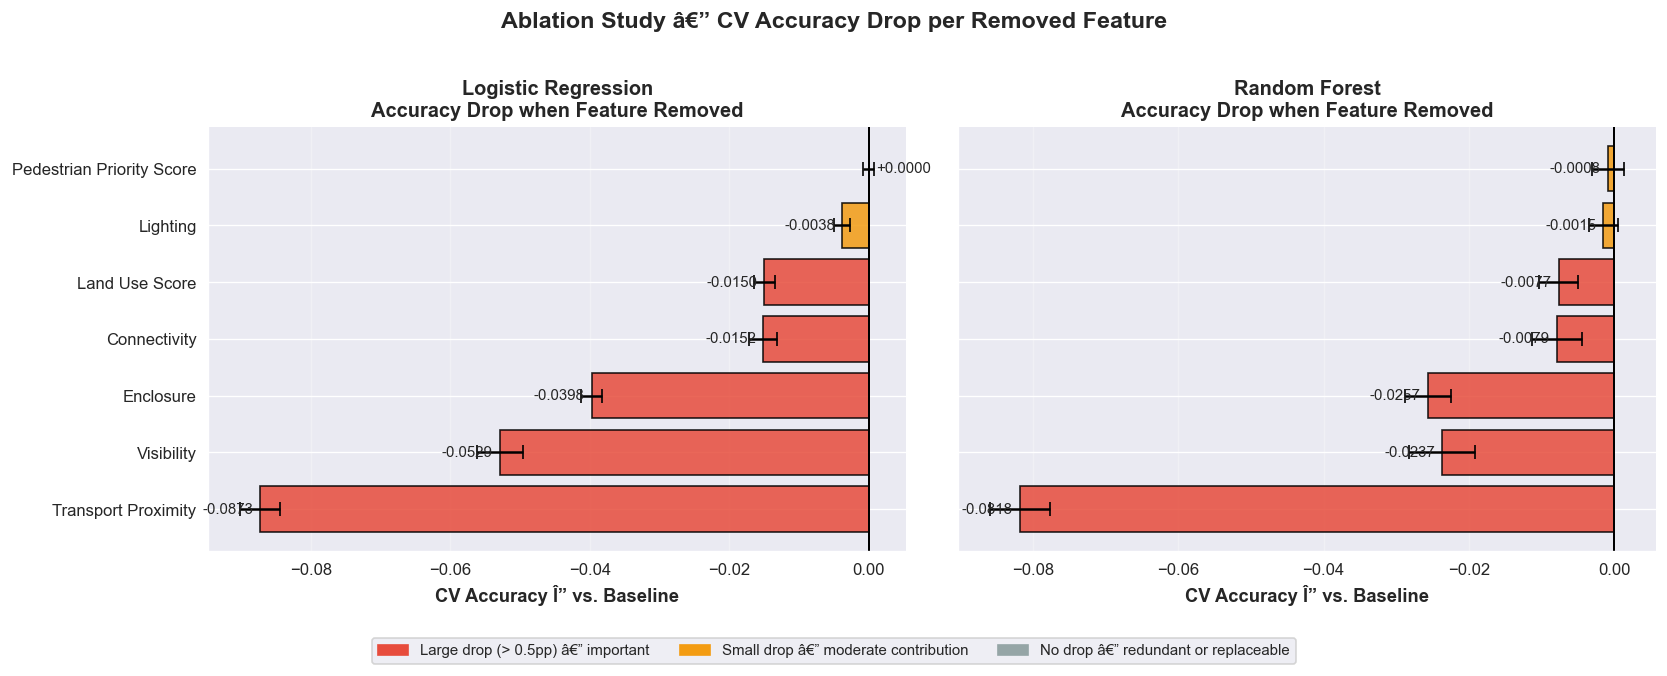

âœ“ Saved C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding - Barcelona\MaCAD26-G01-DataEncoding-BarcelonaVersion\notebooks\plots\ablation\ablation_accuracy_drop.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, model, delta_col, cv_col, cv_std_col, title in zip(
    axes,
    ['LR', 'RF'],
    ['lr_cv_delta', 'rf_cv_delta'],
    ['lr_cv', 'rf_cv'],
    ['lr_cv_std', 'rf_cv_std'],
    ['Logistic Regression', 'Random Forest']
):
    plot_df = ablation_df.sort_values(delta_col)
    colors  = ['#e74c3c' if v < -0.005 else '#f39c12' if v < 0 else '#95a5a6'
               for v in plot_df[delta_col]]

    bars = ax.barh(
        plot_df['dropped_feature'],
        plot_df[delta_col],
        xerr=plot_df[cv_std_col],
        color=colors,
        edgecolor='black',
        alpha=0.85,
        capsize=4
    )
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_xlabel('CV Accuracy Î” vs. Baseline', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nAccuracy Drop when Feature Removed', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate bars with delta values
    for bar, val in zip(bars, plot_df[delta_col]):
        offset = -0.001 if val < 0 else 0.001
        ha     = 'right' if val < 0 else 'left'
        ax.text(
            val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=9
        )

legend_elements = [
    mpatches.Patch(color='#e74c3c', label='Large drop (> 0.5pp) — important'),
    mpatches.Patch(color='#f39c12', label='Small drop — moderate contribution'),
    mpatches.Patch(color='#95a5a6', label='No drop — redundant or replaceable'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08),
           frameon=True, fontsize=9)

plt.suptitle('Ablation Study — CV Accuracy Drop per Removed Feature',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOT_DIR / 'ablation_accuracy_drop.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'âœ“ Saved {PLOT_DIR / "ablation_accuracy_drop.png"}')

## Step 6: Ranked Feature Importance (by Accuracy Drop)

Here we rank features by the average accuracy drop across both models — giving a single, combined importance score.

In [8]:
ablation_df['mean_cv_delta'] = (ablation_df['lr_cv_delta'] + ablation_df['rf_cv_delta']) / 2
ranked = ablation_df[['dropped_feature', 'lr_cv_delta', 'rf_cv_delta', 'mean_cv_delta']].sort_values('mean_cv_delta')

print('Feature ranking by average CV accuracy drop (most to least important):')
print(f'{"Rank":<5} {"Feature":<25} {"LR Î”":>9} {"RF Î”":>9} {"Avg Î”":>9}')
print('-' * 60)
for rank, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"{rank:<5} {row['dropped_feature']:<25} {row['lr_cv_delta']:>+9.4f} {row['rf_cv_delta']:>+9.4f} {row['mean_cv_delta']:>+9.4f}")

print(f"\nMost important feature  : {ranked.iloc[0]['dropped_feature']}  (avg Î” = {ranked.iloc[0]['mean_cv_delta']:+.4f})")
print(f"Least important feature : {ranked.iloc[-1]['dropped_feature']}  (avg Î” = {ranked.iloc[-1]['mean_cv_delta']:+.4f})")

Feature ranking by average CV accuracy drop (most to least important):
Rank  Feature                       LR Î”     RF Î”    Avg Î”
------------------------------------------------------------
1     Transport Proximity         -0.0873   -0.0818   -0.0845
2     Visibility                  -0.0529   -0.0237   -0.0383
3     Enclosure                   -0.0398   -0.0257   -0.0327
4     Connectivity                -0.0152   -0.0079   -0.0115
5     Land Use Score              -0.0150   -0.0077   -0.0113
6     Lighting                    -0.0038   -0.0015   -0.0027
7     Pedestrian Priority Score   +0.0000   -0.0008   -0.0004

Most important feature  : Transport Proximity  (avg Î” = -0.0845)
Least important feature : Pedestrian Priority Score  (avg Î” = -0.0004)


## Step 7: Combined Summary Chart

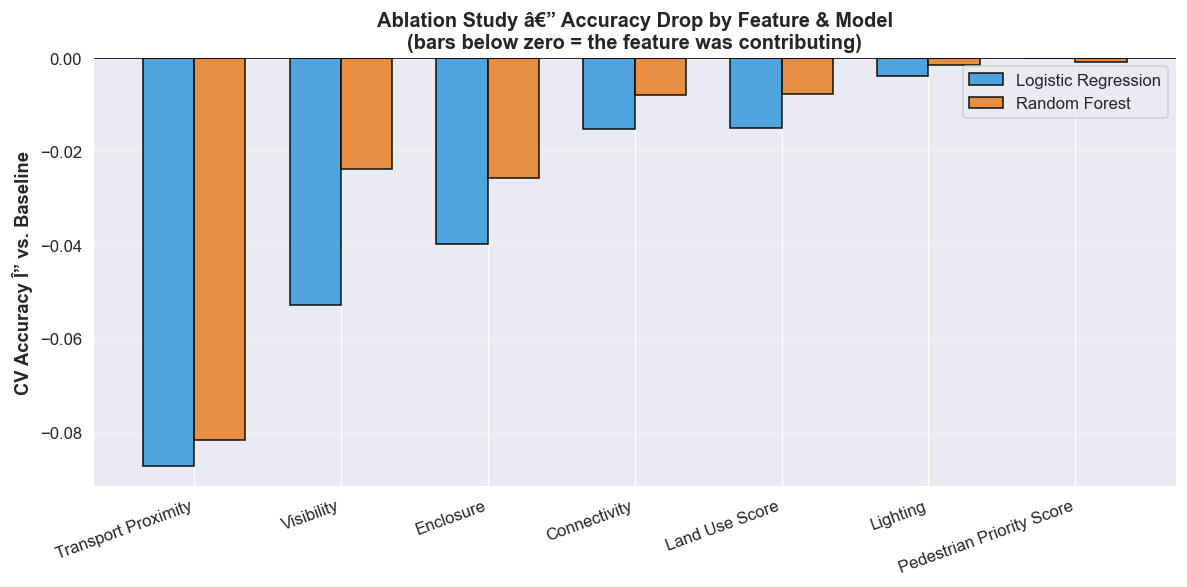

âœ“ Saved C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding - Barcelona\MaCAD26-G01-DataEncoding-BarcelonaVersion\notebooks\plots\ablation\ablation_combined.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(ranked))
width = 0.35

bars_lr = ax.bar(x - width/2, ranked['lr_cv_delta'], width,
                 label='Logistic Regression', color='#3498db', edgecolor='black', alpha=0.85)
bars_rf = ax.bar(x + width/2, ranked['rf_cv_delta'], width,
                 label='Random Forest',       color='#e67e22', edgecolor='black', alpha=0.85)

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(ranked['dropped_feature'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('CV Accuracy Î” vs. Baseline', fontsize=11, fontweight='bold')
ax.set_title('Ablation Study — Accuracy Drop by Feature & Model\n(bars below zero = the feature was contributing)',
             fontsize=12, fontweight='bold')
ax.legend(frameon=True, fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'ablation_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'âœ“ Saved {PLOT_DIR / "ablation_combined.png"}')

## Step 8: Summary

| Setting | Details |
| --- | --- |
| Baseline | All 7 features, same pipeline as `05_ClassificationML.ipynb` |
| Ablation | Drop one feature at a time and compare the CV accuracy deltas |
| Labels | K-Means pseudo-labels from `03_KMeans.ipynb` |